In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

In [2]:
import pandas as pd

demo = pd.read_csv('data/raw/df_final_demo.txt')
experiment = pd.read_csv('data/raw/df_final_experiment_clients.txt')

web_1 = pd.read_csv('data/raw/df_final_web_data_pt_1.txt')
web_2 = pd.read_csv('data/raw/df_final_web_data_pt_2.txt')

In [3]:
print(demo.shape)
print(experiment.shape)
print(web_1.shape)
print(web_2.shape)

(70609, 9)
(70609, 2)
(343141, 5)
(412264, 5)


In [4]:
demo.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0


In [5]:
web_1.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


In [6]:
experiment.head()

,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control


In [7]:
web_2.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,763412,601952081_10457207388,397475557_40440946728_419634,confirm,2017-06-06 08:56:00
1,6019349,442094451_91531546617,154620534_35331068705_522317,confirm,2017-06-01 11:59:27
2,6019349,442094451_91531546617,154620534_35331068705_522317,step_3,2017-06-01 11:58:48
3,6019349,442094451_91531546617,154620534_35331068705_522317,step_2,2017-06-01 11:58:08
4,6019349,442094451_91531546617,154620534_35331068705_522317,step_1,2017-06-01 11:57:58


In [8]:
demo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         70609 non-null  int64  
 1   clnt_tenure_yr    70595 non-null  float64
 2   clnt_tenure_mnth  70595 non-null  float64
 3   clnt_age          70594 non-null  float64
 4   gendr             70595 non-null  object 
 5   num_accts         70595 non-null  float64
 6   bal               70595 non-null  float64
 7   calls_6_mnth      70595 non-null  float64
 8   logons_6_mnth     70595 non-null  float64
dtypes: float64(7), int64(1), object(1)
memory usage: 4.8+ MB


In [9]:
experiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  70609 non-null  int64 
 1   Variation  50500 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.1+ MB


In [10]:
web_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 343141 entries, 0 to 343140
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   client_id     343141 non-null  int64 
 1   visitor_id    343141 non-null  object
 2   visit_id      343141 non-null  object
 3   process_step  343141 non-null  object
 4   date_time     343141 non-null  object
dtypes: int64(1), object(4)
memory usage: 13.1+ MB


In [11]:
print("Demo duplicates:", demo.duplicated().sum())
print("Experiment duplicates:", experiment.duplicated().sum())
print("Web 1 duplicates:", web_1.duplicated().sum())
print("Web 2 duplicates:", web_2.duplicated().sum())

Demo duplicates: 0
Experiment duplicates: 0
Web 1 duplicates: 2095
Web 2 duplicates: 8669


In [12]:
#merge two datasets(pt1 and pt2)
web = pd.concat([web_1, web_2], ignore_index=True)
web.shape

(755405, 5)

In [13]:
web.duplicated().sum()

np.int64(10764)

In [14]:
web = web.drop_duplicates()
web.shape

(744641, 5)

In [15]:
demo.isnull().sum()

client_id            0
clnt_tenure_yr      14
clnt_tenure_mnth    14
clnt_age            15
gendr               14
num_accts           14
bal                 14
calls_6_mnth        14
logons_6_mnth       14
dtype: int64

In [16]:
experiment.isnull().sum()

client_id        0
Variation    20109
dtype: int64

In [17]:
web.isnull().sum()

client_id       0
visitor_id      0
visit_id        0
process_step    0
date_time       0
dtype: int64

In [18]:
demo['gendr'].value_counts(dropna=False)

gendr
U      24122
M      23724
F      22746
NaN       14
X          3
Name: count, dtype: int64

In [19]:
demo = demo[demo['gendr'] != 'X']
#Removed due to unclear category and negligible volume

In [20]:
#clients without experiment assignment
experiment['Variation'].isnull().sum()

np.int64(20109)

In [21]:
#remove clients with no experiment assignement
experiment = experiment.dropna(subset=['Variation'])

In [22]:
#find numerical variables
demo.describe()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,num_accts,bal,calls_6_mnth,logons_6_mnth
count,7.060600e+04,70592.000000,70592.000000,70591.000000,70592.000000,7.059200e+04,70592.000000,70592.000000
mean,5.005032e+06,12.053051,150.660684,46.442542,2.255525,1.474503e+05,3.382465,5.566721
std,2.877313e+06,6.871944,82.091315,15.591381,0.534999,3.015141e+05,2.236587,2.353292
min,1.690000e+02,2.000000,33.000000,13.500000,1.000000,1.378942e+04,0.000000,1.000000
25%,2.519367e+06,6.000000,82.000000,32.500000,2.000000,3.734855e+04,1.000000,4.000000
50%,5.017030e+06,11.000000,136.000000,47.000000,2.000000,6.333658e+04,3.000000,5.000000
75%,7.483198e+06,16.000000,192.000000,59.000000,2.000000,1.375487e+05,6.000000,7.000000
max,9.999839e+06,62.000000,749.000000,96.000000,8.000000,1.632004e+07,7.000000,9.000000


In [23]:
#find categorical vaiables

In [24]:
#gender distribution 
demo['gendr'].value_counts(dropna=False)

gendr
U      24122
M      23724
F      22746
NaN       14
Name: count, dtype: int64

In [25]:
#experiment groups
experiment['Variation'].value_counts(dropna=False)

Variation
Test       26968
Control    23532
Name: count, dtype: int64

In [26]:
#process steps
web['process_step'].value_counts()

process_step
start      234999
step_1     162797
step_2     132750
step_3     111589
confirm    102506
Name: count, dtype: int64

In [27]:
#visual EDA

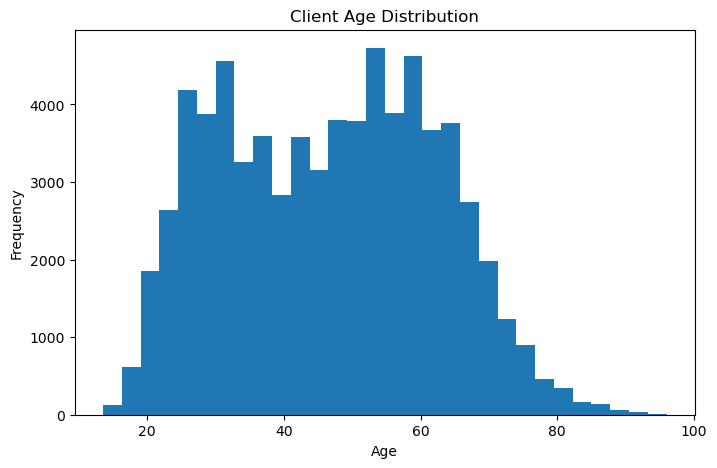

In [28]:
#age distribution 
plt.figure(figsize=(8,5))
plt.hist(demo['clnt_age'].dropna(), bins=30)
plt.title('Client Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [29]:
#Age Distribution Insights
#The online process is mainly used by middle-aged and older clients, especially those between 45 and 60 years old.
#Since older users may experience more usability friction, clearer navigation and interface design could improve completion rates and overall user 
#experience.

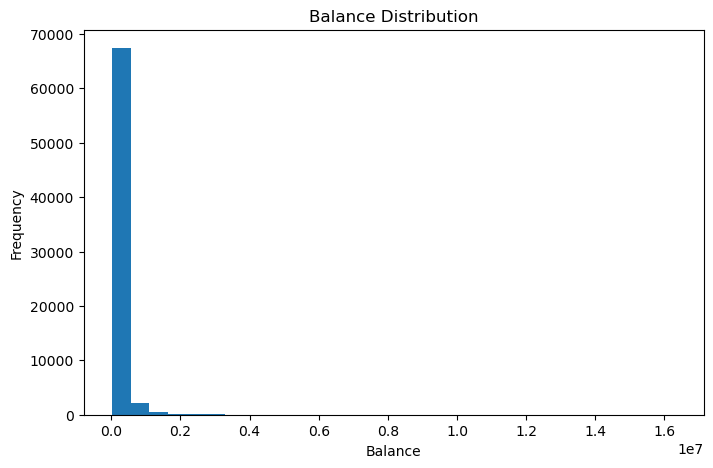

In [30]:
#account balance distribution 
plt.figure(figsize=(8,5))
plt.hist(demo['bal'].dropna(), bins=30)
plt.title('Balance Distribution')
plt.xlabel('Balance')
plt.ylabel('Frequency')
plt.show()

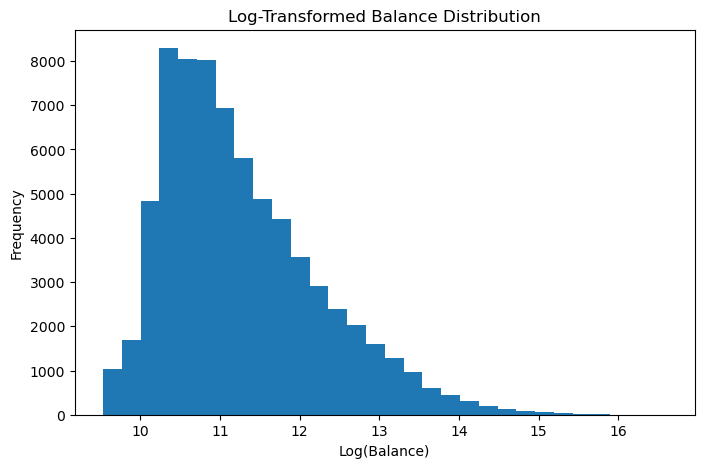

In [31]:
plt.figure(figsize=(8,5))
plt.hist(np.log1p(demo['bal'].dropna()), bins=30)
plt.title('Log-Transformed Balance Distribution')
plt.xlabel('Log(Balance)')
plt.ylabel('Frequency')
plt.show()

In [32]:
#Balance Distribution Insights
#The balance distribution is highly right-skewed. Most clients have moderate balances, while a small number of clients hold very large account balances.
#This suggests Vanguard serves both regular retail investors and some high-value clients

In [33]:
#check unique clients
print("Unique clients in demo:", demo['client_id'].nunique())
print("Unique clients in experiment:", experiment['client_id'].nunique())
print("Unique clients in web:", web['client_id'].nunique())

Unique clients in demo: 70606
Unique clients in experiment: 50500
Unique clients in web: 120157


In [34]:
#convert datetime column
web['date_time'] = pd.to_datetime(web['date_time'])

In [35]:
#check date ranges
print(web['date_time'].min())
print(web['date_time'].max())

2017-03-15 00:03:03
2017-06-20 23:59:57


In [36]:
#session exploration 
web['visitor_id'].nunique()

130236

In [37]:
demo.columns

Index(['client_id', 'clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age', 'gendr',
       'num_accts', 'bal', 'calls_6_mnth', 'logons_6_mnth'],
      dtype='object')

In [38]:
#analyse tenure
demo['clnt_tenure_yr'].describe()

count    70592.000000
mean        12.053051
std          6.871944
min          2.000000
25%          6.000000
50%         11.000000
75%         16.000000
max         62.000000
Name: clnt_tenure_yr, dtype: float64

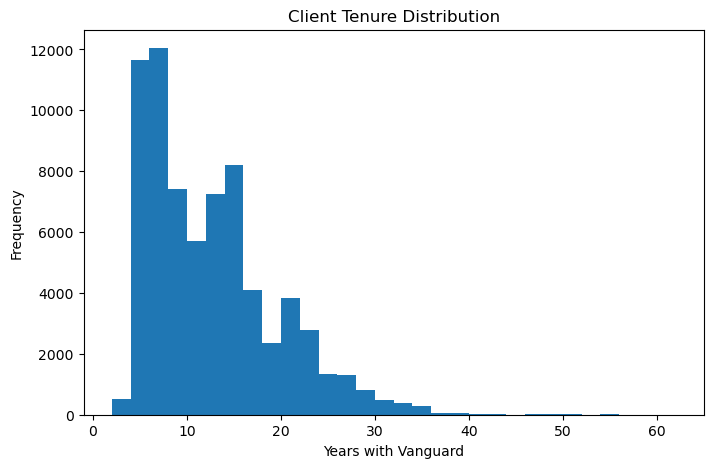

In [39]:
#visualize tenure
plt.figure(figsize=(8,5))
plt.hist(demo['clnt_tenure_yr'].dropna(), bins=30)
plt.title('Client Tenure Distribution')
plt.xlabel('Years with Vanguard')
plt.ylabel('Frequency')
plt.show()

In [40]:
#Client Tenure Insights
#Most users are long-term Vanguard clients, with many having between 5 and 20 years of tenure.
#This suggests the platform is mainly used by experienced and loyal investors, making improvements in the redesigned interface especially meaningful.

In [41]:
#analyze digital activity
demo['logons_6_mnth'].describe()

count    70592.000000
mean         5.566721
std          2.353292
min          1.000000
25%          4.000000
50%          5.000000
75%          7.000000
max          9.000000
Name: logons_6_mnth, dtype: float64

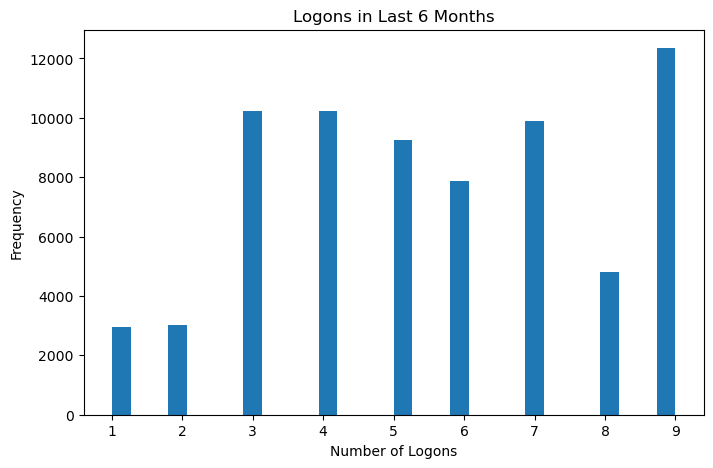

In [42]:
#visualize logoins
plt.figure(figsize=(8,5))
plt.hist(demo['logons_6_mnth'].dropna(), bins=30)
plt.title('Logons in Last 6 Months')
plt.xlabel('Number of Logons')
plt.ylabel('Frequency')
plt.show()

In [43]:
#Digital Engagement Insights

#The logon distribution indicates that many clients interact with Vanguard’s online platform frequently, with most users logging in multiple times 
#during the previous six months.

#This suggests that the experiment primarily involves an already digitally engaged customer base rather than first-time online users. Therefore, 
#improvements in completion behavior are more likely attributable to the redesigned interface itself rather than increased familiarity with digital
#tools.

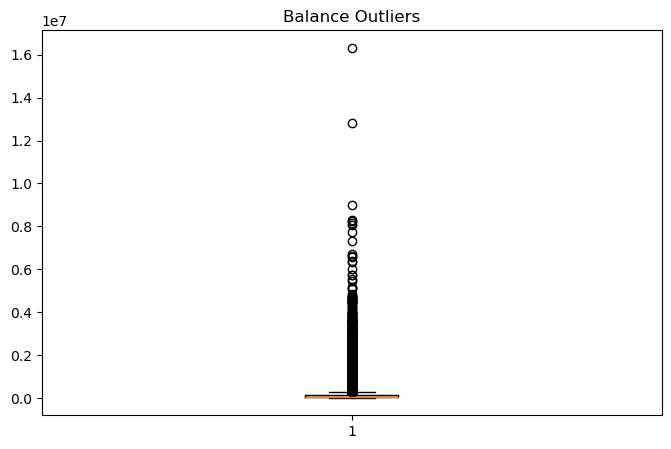

In [44]:
#detect outliers
plt.figure(figsize=(8,5))
plt.boxplot(demo['bal'].dropna())
plt.title('Balance Outliers')
plt.show()

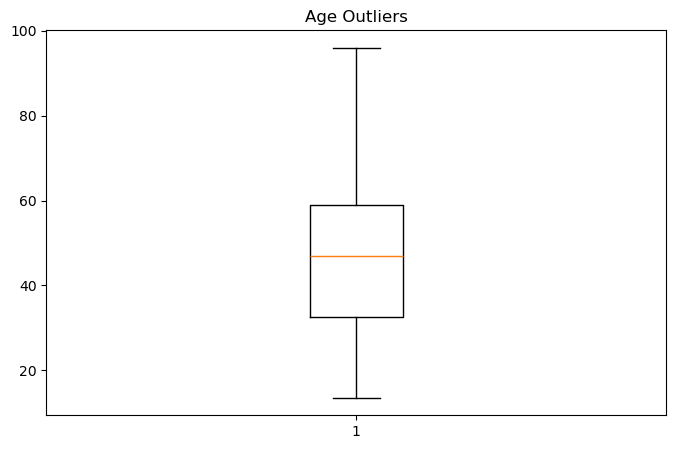

In [45]:
#age outliers
plt.figure(figsize=(8,5))
plt.boxplot(demo['clnt_age'].dropna())
plt.title('Age Outliers')
plt.show()

In [46]:
#balance outliers
Q1 = demo['bal'].quantile(0.25)
Q3 = demo['bal'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(lower)
print(upper)

-112951.67000000004
287848.93000000005


In [47]:
outliers = demo[
    (demo['bal'] < lower) |
    (demo['bal'] > upper)
]
outliers.shape

(8018, 9)

In [48]:
demo.describe()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,num_accts,bal,calls_6_mnth,logons_6_mnth
count,7.060600e+04,70592.000000,70592.000000,70591.000000,70592.000000,7.059200e+04,70592.000000,70592.000000
mean,5.005032e+06,12.053051,150.660684,46.442542,2.255525,1.474503e+05,3.382465,5.566721
std,2.877313e+06,6.871944,82.091315,15.591381,0.534999,3.015141e+05,2.236587,2.353292
min,1.690000e+02,2.000000,33.000000,13.500000,1.000000,1.378942e+04,0.000000,1.000000
25%,2.519367e+06,6.000000,82.000000,32.500000,2.000000,3.734855e+04,1.000000,4.000000
50%,5.017030e+06,11.000000,136.000000,47.000000,2.000000,6.333658e+04,3.000000,5.000000
75%,7.483198e+06,16.000000,192.000000,59.000000,2.000000,1.375487e+05,6.000000,7.000000
max,9.999839e+06,62.000000,749.000000,96.000000,8.000000,1.632004e+07,7.000000,9.000000


In [49]:
#Outlier Analysis

#Outliers were explored using descriptive statistics and boxplots. High balance values were retained because they likely represent real high-value 
#clients rather than data errors. Most variables showed realistic ranges, although a small number of unusually young clients may optionally be 
#excluded from the analysis.

In [50]:
demo.isnull().all(axis=1).sum()

np.int64(0)

In [51]:
experiment.isnull().all(axis=1).sum()

np.int64(0)

In [52]:
web.isnull().all(axis=1).sum()

np.int64(0)

In [53]:
experiment['Variation'].isnull().sum()

np.int64(0)

In [54]:
df = ( web
    .merge(experiment, on='client_id', how='left')
    .merge(demo, on='client_id', how='left'))

In [55]:
df_exp = df[
    df['Variation'].isin(['Control', 'Test'])]

## KPI Analysis

In [59]:
#KPI 1 - Completion Rate ( clients reaching confirm ) 
completion = ( df_exp
    .groupby(['client_id', 'Variation'])['process_step']
    .apply(lambda x: 'confirm' in x.values)
    .reset_index(name='completed'))
completion.head()

,client_id,Variation,completed
0,555,Test,True
1,647,Test,True
2,934,Test,False
3,1028,Control,False
4,1104,Control,False


In [60]:
#Completion Rate by Group
completion_rate = (completion
    .groupby('Variation')
    .agg(
        total_clients=('client_id', 'nunique'),
        completed_clients=('completed', 'sum')
    ).reset_index())

completion_rate['completion_rate'] = (
    completion_rate['completed_clients']
    / completion_rate['total_clients'])
completion_rate

,Variation,total_clients,completed_clients,completion_rate
0,Control,23532,15434,0.655873
1,Test,26968,18687,0.692932


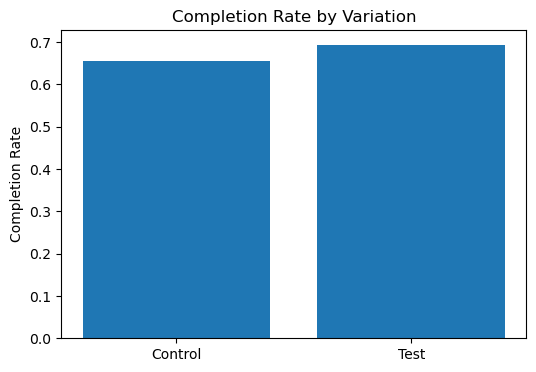

In [61]:
#Visualize Completion Rate 
plt.figure(figsize=(6,4))
plt.bar(
    completion_rate['Variation'],
    completion_rate['completion_rate'])
plt.title('Completion Rate by Variation')
plt.ylabel('Completion Rate')
plt.show()

In [62]:
#KPI 2 — Time Spent on Each Step ( seconds between consecutive events in same visit) 
#sort 
df_time = df_exp.sort_values(['client_id', 'visit_id', 'date_time']).copy()

In [63]:
#calculate step duration 
df_time = df_exp.sort_values(['client_id', 'visit_id', 'date_time']).copy()

df_time['next_time'] = (
    df_time
    .groupby(['client_id', 'visit_id'])['date_time']
    .shift(-1)
)

df_time['step_duration_sec'] = (
    df_time['next_time'] - df_time['date_time']
).dt.total_seconds()

In [64]:
#Remove Negative / Extreme Durations
df_time = df_time[
    (df_time['step_duration_sec'] >= 0) &
    (df_time['step_duration_sec'] <= 1800)
]

In [65]:
#Average Time Per Step
step_time = (
    df_time
    .groupby(['Variation', 'process_step'])
    .agg(avg_time_sec=('step_duration_sec', 'mean'))
    .reset_index()
)

step_time

,Variation,process_step,avg_time_sec
0,Control,confirm,145.541732
1,Control,start,60.881279
2,Control,step_1,47.460199
3,Control,step_2,90.175377
4,Control,step_3,133.298306
5,Test,confirm,217.719822
6,Test,start,56.257391
7,Test,step_1,58.483000
8,Test,step_2,88.106906
9,Test,step_3,124.820947


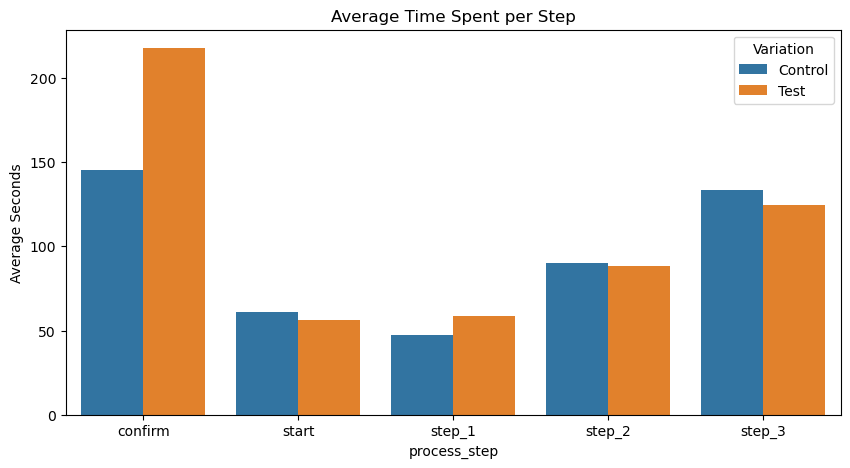

In [66]:
#Visualize Step Duration
import seaborn as sns
plt.figure(figsize=(10,5))
sns.barplot( data=step_time, x='process_step', y='avg_time_sec', hue='Variation')
plt.title('Average Time Spent per Step')
plt.ylabel('Average Seconds')
plt.show()

In [67]:
#KPI 3 — Error Rate (Backtracking, step visits where users moved to a previous step ) 
#define step order 
step_order = {'start': 0, 'step_1': 1, 'step_2': 2, 'step_3': 3, 'confirm': 4}

In [68]:
df_exp = df_exp.sort_values(['client_id', 'visit_id', 'date_time']).copy()

In [69]:
#convert steps to numeric
df_exp['step_num'] = (df_exp['process_step'].map(step_order))

In [70]:
df_exp['previous_step'] = (df_exp
    .groupby(['client_id', 'visit_id'])['step_num']
    .shift(1))
df_exp['backtrack'] = (
    (df_exp['step_num'] < df_exp['previous_step']) &
    (df_exp['step_num'].notna()) &
    (df_exp['previous_step'].notna())
)

In [71]:
#error rate by group
error_rate = (df_exp
    .groupby('Variation')
    .agg(
        total_actions=('backtrack', 'count'),
        backtracks=('backtrack', 'sum') ) .reset_index())
error_rate['error_rate'] = (error_rate['backtracks']/ error_rate['total_actions'])
error_rate

,Variation,total_actions,backtracks,error_rate
0,Control,140536,9581,0.068175
1,Test,176699,16232,0.091862


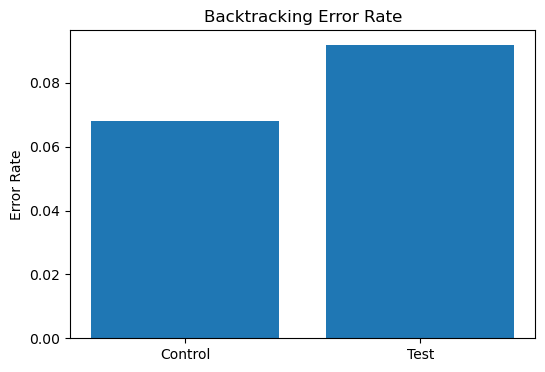

In [72]:
#Visualize error rate 
plt.figure(figsize=(6,4))
plt.bar(error_rate['Variation'],error_rate['error_rate'])
plt.title('Backtracking Error Rate')
plt.ylabel('Error Rate')
plt.show()

In [73]:
# Percentage of visits with at least one backtracking error
# Identify if every visit had an error
visit_error_rate = (
    df_exp
    .groupby(['Variation', 'visit_id'])
    .agg(has_error=('backtrack', 'max'))
    .reset_index()
)


In [74]:
# Group previous info (Control and Test)
visit_error_rate_summary = (
    visit_error_rate
    .groupby('Variation')
    .agg(
        total_visits=('visit_id', 'count'),
        visits_with_error=('has_error', 'sum')
    )
    .reset_index()
)

In [75]:
#Get each percentage

visit_error_rate_summary['visit_error_rate'] = (
    visit_error_rate_summary['visits_with_error'] /
    visit_error_rate_summary['total_visits']
)

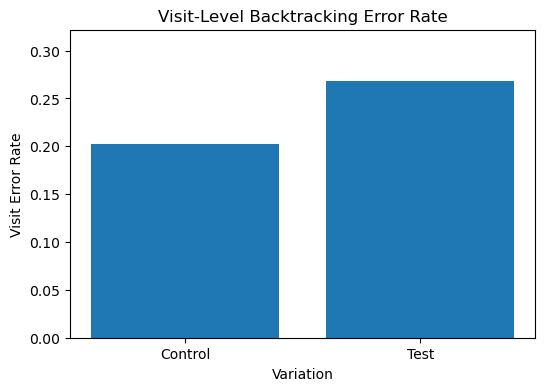

In [76]:
# Visualize visit-level error rate

plt.figure(figsize=(6,4))
plt.bar(
    visit_error_rate_summary['Variation'],
    visit_error_rate_summary['visit_error_rate']
)

plt.title('Visit-Level Backtracking Error Rate')
plt.xlabel('Variation')
plt.ylabel('Visit Error Rate')
plt.ylim(0, visit_error_rate_summary['visit_error_rate'].max() * 1.2)

plt.show()

In [77]:
#KPI 4 - Drop off Rate ( % of users who started but did not confirm or lost between each consecutive step)
# Drop-off Rate =(users who started but did not confirm)/ users who started

# Visits that started but did not reach confirmation
visit_steps = (
    df_exp
    .groupby(['Variation', 'visit_id'])['process_step']
    .agg(list)
    .reset_index()
)

visit_steps.head()



,Variation,visit_id,process_step
0,Control,100030127_47967100085_936361,[start]
1,Control,100037962_47432393712_705583,"[start, start, step_1, start]"
2,Control,100057941_88477660212_944512,"[start, step_1, step_2, step_3, step_1, step_2..."
3,Control,10006594_66157970412_679648,"[start, step_1, step_2, step_3, step_3, confir..."
4,Control,100071743_53464757454_616703,[start]


In [78]:
# Check if visit reached confirmation

visit_steps['completed'] = (
    visit_steps['process_step']
    .apply(lambda x: 'confirm' in x)
)

visit_steps.head()

,Variation,visit_id,process_step,completed
0,Control,100030127_47967100085_936361,[start],False
1,Control,100037962_47432393712_705583,"[start, start, step_1, start]",False
2,Control,100057941_88477660212_944512,"[start, step_1, step_2, step_3, step_1, step_2...",False
3,Control,10006594_66157970412_679648,"[start, step_1, step_2, step_3, step_3, confir...",True
4,Control,100071743_53464757454_616703,[start],False


In [79]:
# Calculate drop-off rate by group

dropoff_summary = (
    visit_steps
    .groupby('Variation')
    .agg(
        total_visits=('visit_id', 'count'),
        completed_visits=('completed', 'sum')
    )
    .reset_index()
)

dropoff_summary['dropoff_visits'] = (
    dropoff_summary['total_visits'] -
    dropoff_summary['completed_visits']
)

dropoff_summary['dropoff_rate'] = (
    dropoff_summary['dropoff_visits'] /
    dropoff_summary['total_visits']
)

dropoff_summary

,Variation,total_visits,completed_visits,dropoff_visits,dropoff_rate
0,Control,32189,16046,16143,0.501507
1,Test,37136,21731,15405,0.414827


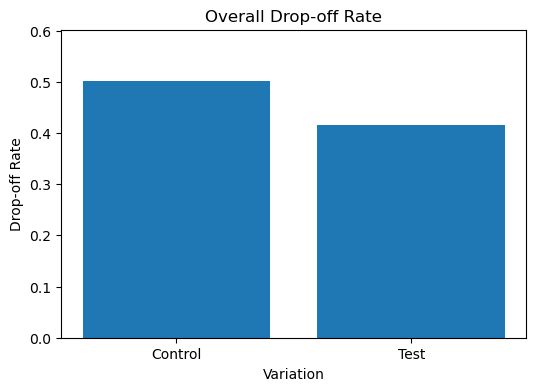

In [80]:
# Visualize overall drop-off rate

plt.figure(figsize=(6,4))

plt.bar(
    dropoff_summary['Variation'],
    dropoff_summary['dropoff_rate']
)

plt.title('Overall Drop-off Rate')
plt.xlabel('Variation')
plt.ylabel('Drop-off Rate')

plt.ylim(0, dropoff_summary['dropoff_rate'].max() * 1.2)

plt.show()

The redesigned interface reduced the overall drop-off rate. Control users had a drop-off rate of 50.15%, while Test users had a lower drop-off rate of 41.48%. This suggests that the new digital experience helped more users continue through the process and reach confirmation.

In [81]:
# KPI 4 — Step-by-step Funnel Drop-off

funnel_steps = ['start', 'step_1', 'step_2', 'step_3', 'confirm']

In [82]:
#Count of visits by steps
funnel_counts = (
    df_exp[df_exp['process_step'].isin(funnel_steps)]
    .groupby(['Variation', 'process_step'])
    .agg(visits=('visit_id', 'nunique'))
    .reset_index()
)

funnel_counts

,Variation,process_step,visits
0,Control,confirm,16046
1,Control,start,30910
2,Control,step_1,23548
3,Control,step_2,20138
4,Control,step_3,18300
5,Test,confirm,21731
6,Test,start,33157
7,Test,step_1,28285
8,Test,step_2,24503
9,Test,step_3,22186


In [83]:
#Count of visits by steps and by groups (Control vs Test)
funnel_counts['process_step'] = pd.Categorical(
    funnel_counts['process_step'],
    categories=funnel_steps,
    ordered=True
)

funnel_counts = funnel_counts.sort_values(['Variation', 'process_step'])

funnel_counts

,Variation,process_step,visits
1,Control,start,30910
2,Control,step_1,23548
3,Control,step_2,20138
4,Control,step_3,18300
0,Control,confirm,16046
6,Test,start,33157
7,Test,step_1,28285
8,Test,step_2,24503
9,Test,step_3,22186
5,Test,confirm,21731


In [84]:
#Calculate visits from previous step
funnel_counts['previous_visits'] = (
    funnel_counts
    .groupby('Variation')['visits']
    .shift(1)
)

funnel_counts

,Variation,process_step,visits,previous_visits
1,Control,start,30910,NaN
2,Control,step_1,23548,30910.0
3,Control,step_2,20138,23548.0
4,Control,step_3,18300,20138.0
0,Control,confirm,16046,18300.0
6,Test,start,33157,NaN
7,Test,step_1,28285,33157.0
8,Test,step_2,24503,28285.0
9,Test,step_3,22186,24503.0
5,Test,confirm,21731,22186.0


In [85]:
#Calculate drop-offs between steps
funnel_counts['step_dropoff'] = (
    funnel_counts['previous_visits'] - funnel_counts['visits']
)

funnel_counts['step_dropoff_rate'] = (
    funnel_counts['step_dropoff'] / funnel_counts['previous_visits']
)

funnel_counts

,Variation,process_step,visits,previous_visits,step_dropoff,step_dropoff_rate
1,Control,start,30910,NaN,NaN,NaN
2,Control,step_1,23548,30910.0,7362.0,0.238175
3,Control,step_2,20138,23548.0,3410.0,0.144811
4,Control,step_3,18300,20138.0,1838.0,0.091270
0,Control,confirm,16046,18300.0,2254.0,0.123169
6,Test,start,33157,NaN,NaN,NaN
7,Test,step_1,28285,33157.0,4872.0,0.146937
8,Test,step_2,24503,28285.0,3782.0,0.133710
9,Test,step_3,22186,24503.0,2317.0,0.094560
5,Test,confirm,21731,22186.0,455.0,0.020508


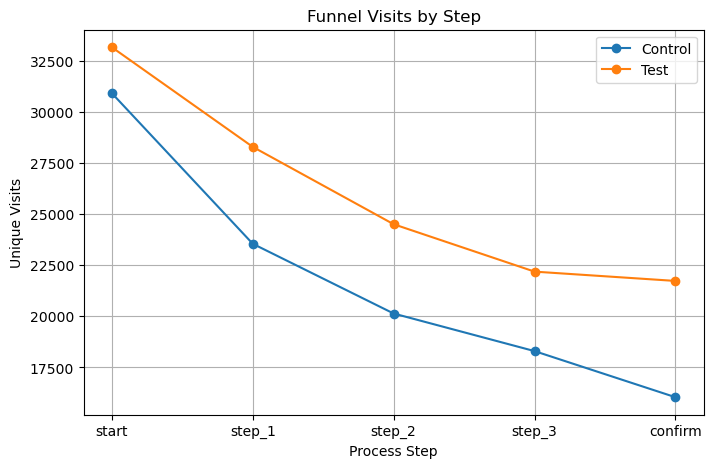

In [86]:
# Visualize funnel visits by step

plt.figure(figsize=(8,5))

for variation in funnel_counts['Variation'].unique():
    data = funnel_counts[funnel_counts['Variation'] == variation]
    plt.plot(
        data['process_step'],
        data['visits'],
        marker='o',
        label=variation
    )

plt.title('Funnel Visits by Step')
plt.xlabel('Process Step')
plt.ylabel('Unique Visits')
plt.legend()
plt.grid(True)

plt.show()

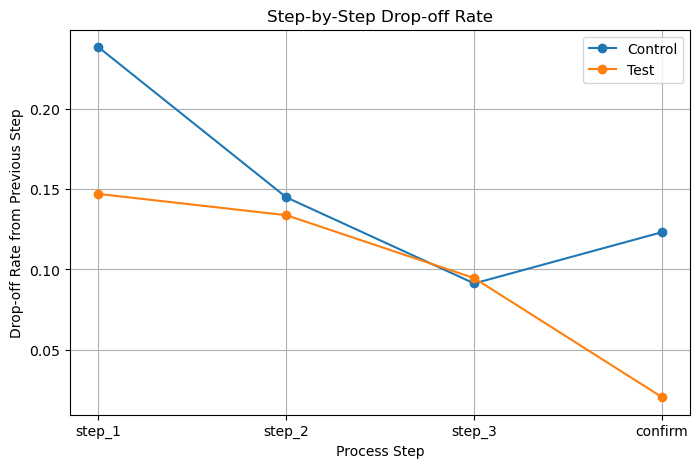

In [87]:
# Visualize step-by-step drop-off rate

dropoff_steps = funnel_counts.dropna(subset=['step_dropoff_rate'])

plt.figure(figsize=(8,5))

for variation in dropoff_steps['Variation'].unique():
    data = dropoff_steps[dropoff_steps['Variation'] == variation]
    plt.plot(
        data['process_step'],
        data['step_dropoff_rate'],
        marker='o',
        label=variation
    )

plt.title('Step-by-Step Drop-off Rate')
plt.xlabel('Process Step')
plt.ylabel('Drop-off Rate from Previous Step')
plt.legend()
plt.grid(True)

plt.show()

The redesigned interface significantly improved funnel retention. The Test group experienced lower drop-off rates across most funnel transitions, particularly in the final conversion stage from step_3 to confirmation, where abandonment dropped dramatically compared to the Control group. This suggests that the redesigned experience created a smoother and more effective completion flow.

In [88]:
# KPI 5 — Repeat Step Rate
""" KPI 5 - Repeat Step Rate (users repeating the same step multiple times) could indicate confusion, 
unclear instructions and technical friction """

# Users repeating the same step multiple times

df_repeat = df_exp.sort_values(
    ['client_id', 'visit_id', 'date_time']
).copy()

In [89]:
# Previous step within same visit

df_repeat['previous_step_same_visit'] = (
    df_repeat
    .groupby(['client_id', 'visit_id'])['process_step']
    .shift(1)
)

df_repeat.head()

,client_id,visitor_id,visit_id,process_step,date_time,Variation,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,step_num,previous_step,backtrack,previous_step_same_visit
71583,555,402506806_56087378777,637149525_38041617439_716659,start,2017-04-15 12:57:56,Test,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,0,NaN,False,NaN
71582,555,402506806_56087378777,637149525_38041617439_716659,step_1,2017-04-15 12:58:03,Test,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,1,0.0,False,start
71581,555,402506806_56087378777,637149525_38041617439_716659,step_2,2017-04-15 12:58:35,Test,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,2,1.0,False,step_1
71580,555,402506806_56087378777,637149525_38041617439_716659,step_3,2017-04-15 13:00:14,Test,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,3,2.0,False,step_2
71579,555,402506806_56087378777,637149525_38041617439_716659,confirm,2017-04-15 13:00:34,Test,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,4,3.0,False,step_3


In [90]:
# Detect repeated steps

df_repeat['repeated_step'] = (
    df_repeat['process_step'] ==
    df_repeat['previous_step_same_visit']
)

df_repeat.head()

,client_id,visitor_id,visit_id,process_step,date_time,Variation,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,step_num,previous_step,backtrack,previous_step_same_visit,repeated_step
71583,555,402506806_56087378777,637149525_38041617439_716659,start,2017-04-15 12:57:56,Test,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,0,NaN,False,NaN,False
71582,555,402506806_56087378777,637149525_38041617439_716659,step_1,2017-04-15 12:58:03,Test,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,1,0.0,False,start,False
71581,555,402506806_56087378777,637149525_38041617439_716659,step_2,2017-04-15 12:58:35,Test,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,2,1.0,False,step_1,False
71580,555,402506806_56087378777,637149525_38041617439_716659,step_3,2017-04-15 13:00:14,Test,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,3,2.0,False,step_2,False
71579,555,402506806_56087378777,637149525_38041617439_716659,confirm,2017-04-15 13:00:34,Test,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,4,3.0,False,step_3,False


In [91]:
# Calculate repeat step rate by group

repeat_step_rate = (
    df_repeat
    .groupby('Variation')
    .agg(
        total_actions=('repeated_step', 'count'),
        repeated_actions=('repeated_step', 'sum')
    )
    .reset_index()
)

repeat_step_rate['repeat_step_rate'] = (
    repeat_step_rate['repeated_actions'] /
    repeat_step_rate['total_actions']
)

repeat_step_rate

,Variation,total_actions,repeated_actions,repeat_step_rate
0,Control,140536,13674,0.097299
1,Test,176699,19016,0.107618


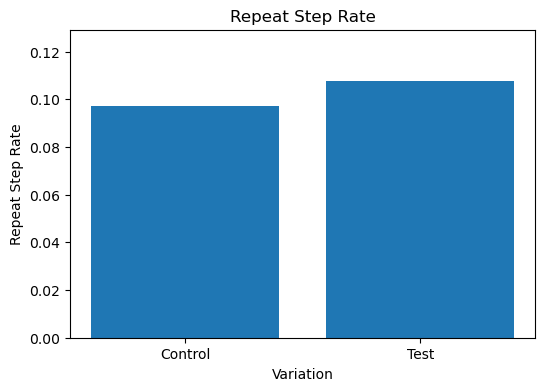

In [92]:
# Visualize repeat step rate

plt.figure(figsize=(6,4))

plt.bar(
    repeat_step_rate['Variation'],
    repeat_step_rate['repeat_step_rate']
)

plt.title('Repeat Step Rate')
plt.xlabel('Variation')
plt.ylabel('Repeat Step Rate')

plt.ylim(0, repeat_step_rate['repeat_step_rate'].max() * 1.2)

plt.show()

The Test group showed a slightly higher repeat step rate compared to the Control group. This suggests that users interacting with the redesigned interface repeated the same steps more frequently, potentially indicating confusion, unclear guidance, or interaction friction within certain stages of the process.

In [93]:
#Due to previous result, review where are people going back mostly from each group

# Repeat step rate by process step

repeat_by_step = (
    df_repeat
    .groupby(['Variation', 'process_step'])
    .agg(
        total_actions=('repeated_step', 'count'),
        repeated_actions=('repeated_step', 'sum')
    )
    .reset_index()
)

repeat_by_step['repeat_rate'] = (
    repeat_by_step['repeated_actions'] /
    repeat_by_step['total_actions']
)

repeat_by_step

,Variation,process_step,total_actions,repeated_actions,repeat_rate
0,Control,confirm,17336,1239,0.071470
1,Control,start,45380,9660,0.212869
2,Control,step_1,29544,1186,0.040144
3,Control,step_2,25773,839,0.032553
4,Control,step_3,22503,750,0.033329
5,Test,confirm,25600,3784,0.147813
6,Test,start,55773,12202,0.218780
7,Test,step_1,38666,1573,0.040682
8,Test,step_2,30899,581,0.018803
9,Test,step_3,25761,876,0.034005


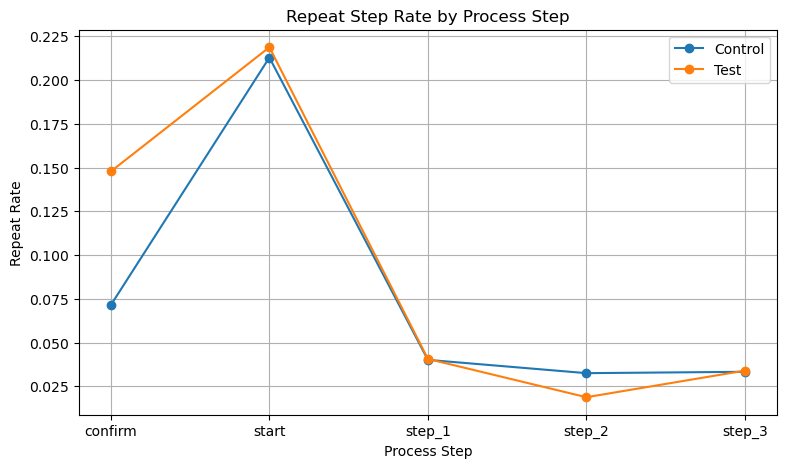

In [94]:
# Visualize repeat rate by process step

plt.figure(figsize=(9,5))

for variation in repeat_by_step['Variation'].unique():
    
    data = repeat_by_step[
        repeat_by_step['Variation'] == variation
    ]
    
    plt.plot(
        data['process_step'],
        data['repeat_rate'],
        marker='o',
        label=variation
    )

plt.title('Repeat Step Rate by Process Step')
plt.xlabel('Process Step')
plt.ylabel('Repeat Rate')

plt.legend()
plt.grid(True)

plt.show()

The redesigned experience improved conversion performance and reduced funnel abandonment. However, users in the Test group showed significantly higher repetition rates at the confirmation stage, suggesting uncertainty or insufficient feedback after completing the process. This indicates that while the redesign improved overall flow efficiency, the final confirmation interaction may require UX refinements to reduce repeated actions and user hesitation.

In [95]:
#KPI 6  - Repeat visit Rate ( % of clients with more than 1 visit session ) 

# Percentage of clients with more than one visit session

client_visits = (
    df_exp
    .groupby(['Variation', 'client_id'])
    .agg(
        total_visits=('visit_id', 'nunique')
    )
    .reset_index()
)

client_visits.head()

,Variation,client_id,total_visits
0,Control,1028,1
1,Control,1104,2
2,Control,1186,2
3,Control,1195,1
4,Control,1197,1


In [96]:
# Flag clients with more than one visit

client_visits['repeat_visitor'] = (
    client_visits['total_visits'] > 1
)

client_visits.head()

,Variation,client_id,total_visits,repeat_visitor
0,Control,1028,1,False
1,Control,1104,2,True
2,Control,1186,2,True
3,Control,1195,1,False
4,Control,1197,1,False


In [97]:
# Calculate repeat visit rate by group

repeat_visit_rate = (
    client_visits
    .groupby('Variation')
    .agg(
        total_clients=('client_id', 'count'),
        repeat_visitors=('repeat_visitor', 'sum')
    )
    .reset_index()
)

repeat_visit_rate['repeat_visit_rate'] = (
    repeat_visit_rate['repeat_visitors'] /
    repeat_visit_rate['total_clients']
)

repeat_visit_rate

,Variation,total_clients,repeat_visitors,repeat_visit_rate
0,Control,23532,5904,0.250892
1,Test,26968,7092,0.262978


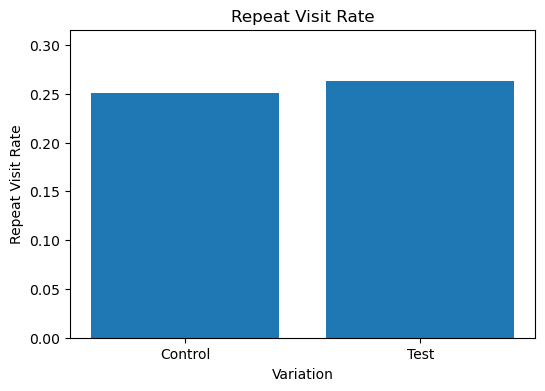

In [98]:
# Visualize repeat visit rate

plt.figure(figsize=(6,4))

plt.bar(
    repeat_visit_rate['Variation'],
    repeat_visit_rate['repeat_visit_rate']
)

plt.title('Repeat Visit Rate')
plt.xlabel('Variation')
plt.ylabel('Repeat Visit Rate')

plt.ylim(0, repeat_visit_rate['repeat_visit_rate'].max() * 1.2)

plt.show()

Some users interacted with the redesigned experience across multiple sessions while still achieving higher completion outcomes overall.

## Conclusion

The redesigned digital experience improved overall process completion and reduced abandonment throughout the funnel. Users in the Test group progressed more successfully through each stage and reached confirmation more frequently than users in the Control group.

However, behavioral metrics such as higher backtracking rates, increased repeated step interactions, and slightly higher repeat visit rates suggest that some parts of the redesigned experience may still generate friction or uncertainty for users.

In particular, the confirmation stage showed a significantly higher repetition rate in the Test group, indicating that users may require clearer feedback or confirmation cues at the end of the process.

Overall, the redesign appears successful from a conversion perspective, but further UX refinements could improve navigation clarity and reduce unnecessary repeated interactions.

# Hypotheses Testing

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import mannwhitneyu

In [100]:
df_hyp = df_exp.copy() #The dataframe for the hypothesis to avoid changing the finished one

Significance level: α = 0.05

In [102]:
df_hyp.head()

,client_id,visitor_id,visit_id,process_step,date_time,Variation,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,step_num,previous_step,backtrack
71583,555,402506806_56087378777,637149525_38041617439_716659,start,2017-04-15 12:57:56,Test,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,0,NaN,False
71582,555,402506806_56087378777,637149525_38041617439_716659,step_1,2017-04-15 12:58:03,Test,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,1,0.0,False
71581,555,402506806_56087378777,637149525_38041617439_716659,step_2,2017-04-15 12:58:35,Test,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,2,1.0,False
71580,555,402506806_56087378777,637149525_38041617439_716659,step_3,2017-04-15 13:00:14,Test,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,3,2.0,False
71579,555,402506806_56087378777,637149525_38041617439_716659,confirm,2017-04-15 13:00:34,Test,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,4,3.0,False


## Completion rate 

### Hypothesis

H0: The completion rate is the same in the Control and Test groups.

H1: The completion rate is different between the Control and Test groups.

In [103]:
completion = (
    df_hyp
    .groupby(['Variation', 'client_id'])
    .agg(
        completed=('process_step', lambda x: 'confirm' in x.values)
    )
    .reset_index()
)

completion.head()

,Variation,client_id,completed
0,Control,1028,False
1,Control,1104,False
2,Control,1186,False
3,Control,1195,True
4,Control,1197,True


In [104]:
#Group them by control or test

completion_summary = (
    completion
    .groupby('Variation')
    .agg(
        total_clients=('client_id', 'count'),
        completed_clients=('completed', 'sum')
    )
    .reset_index()
)

In [105]:
#Calculate completion rate

completion_summary['completion_rate'] = (
    completion_summary['completed_clients'] /
    completion_summary['total_clients']
)

completion_summary

,Variation,total_clients,completed_clients,completion_rate
0,Control,23532,15434,0.655873
1,Test,26968,18687,0.692932


In [106]:
#Proportions z-test since we are comparing proportions (completion rate)

count = completion_summary['completed_clients'].values
nobs = completion_summary['total_clients'].values

z_stat, p_value = proportions_ztest(count, nobs)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: -8.8745141890702
P-value: 7.023933247581433e-19


In [107]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0: The difference in completion rate is statistically significant.")
else:
    print("Fail to reject H0: The difference in completion rate is not statistically significant.")

Reject H0: The difference in completion rate is statistically significant.


### Visualization

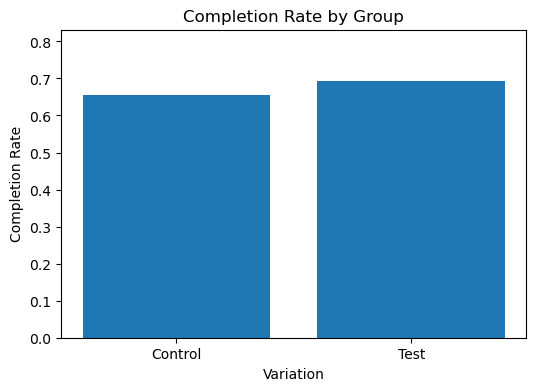

In [108]:
plt.figure(figsize=(6,4))

plt.bar(
    completion_summary['Variation'],
    completion_summary['completion_rate']
)

plt.title('Completion Rate by Group')
plt.xlabel('Variation')
plt.ylabel('Completion Rate')
plt.ylim(0, completion_summary['completion_rate'].max() * 1.2)

plt.show()

### Statistical Conclusion

The completion rate difference between the Control and Test groups is statistically significant (p < 0.05).

Therefore, we reject the null hypothesis and conclude that the redesign had a significant impact on the completion rate.

In [109]:
# Double-checking how much improvement or difference we got

control_rate = completion_summary.loc[
    completion_summary['Variation'] == 'Control',
    'completion_rate'
].iloc[0]

test_rate = completion_summary.loc[
    completion_summary['Variation'] == 'Test',
    'completion_rate'
].iloc[0]

absolute_lift = test_rate - control_rate

relative_lift = absolute_lift / control_rate

print(f"Control Completion Rate: {control_rate:.2%}")
print(f"Test Completion Rate: {test_rate:.2%}")
print(f"Absolute Lift: {absolute_lift:.2%}")
print(f"Relative Lift: {relative_lift:.2%}")

Control Completion Rate: 65.59%
Test Completion Rate: 69.29%
Absolute Lift: 3.71%
Relative Lift: 5.65%


## Completion rate with the cost-effect

### Hypothesis

H0: 

H1: 